# Installation MMPose

In [1]:
# ✅ Toujours utiliser %pip dans Colab
%pip uninstall -y mmpose mmcv mmcv-lite mmdet >/dev/null 2>&1

# mmcv-lite en premier, PAS de C++ ops
%pip install -q mmcv-lite==2.0.1

# mmdet sans deps pour ne PAS tirer "mmcv" full
%pip install -q --no-deps mmdet==3.3.0

# Récupère le code MMPose v1.3.2 et PATCH pour éviter l'import des têtes "transformer"
import os, shutil, subprocess, textwrap, sys
repo = "/content/mmpose_cpu_patch"
shutil.rmtree(repo, ignore_errors=True)
subprocess.check_call(["git","clone","--depth","1","--branch","v1.3.2",
                       "https://github.com/open-mmlab/mmpose.git", repo])

# 1) Retirer 'chumpy' (inutile en 2D et problématique en Py3.12)
for meta in ("setup.cfg","pyproject.toml"):
    p = os.path.join(repo, meta)
    if os.path.exists(p):
        s = open(p,"r",encoding="utf-8").read().replace("chumpy","")
        open(p,"w",encoding="utf-8").write(s)

# 2) Désactiver totalement les "transformer_heads" (EDPose)
heads_init = os.path.join(repo, "mmpose/models/heads/__init__.py")
if os.path.exists(heads_init):
    s = open(heads_init,"r",encoding="utf-8").read()
    # supprime toute ligne qui importe transformer_heads
    s = "\n".join([ln for ln in s.splitlines() if "transformer_heads" not in ln])
    open(heads_init,"w",encoding="utf-8").write(s)

# 3) Supprime le dossier des transformer_heads pour être 100% safe
tf_dir = os.path.join(repo, "mmpose/models/heads/transformer_heads")
shutil.rmtree(tf_dir, ignore_errors=True)

# Installe le paquet patché (non-editable pour éviter les soucis de chemins)
%pip install -q /content/mmpose_cpu_patch

# Sanity checks
import importlib.util, pkgutil, mmcv, mmpose
print("mmcv version:", getattr(mmcv, "__version__", "N/A"))
print("mmcv._ext chargeable ?",
      end=" ")
try:
    import mmcv._ext as _ext
    print("Oui (peu probable en CPU).")
except Exception as e:
    print("Non (c'est attendu en CPU).")
print("mmpose file:", getattr(mmpose, "__file__", None))
print("mmpose.apis visible ?",
      importlib.util.find_spec("mmpose.apis") is not None)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
mmcv version: 2.0.1
mmcv._ext chargeable ? Non (c'est attendu en CPU).
mmpose file: /usr/local/lib/python3.12/dist-packages/mmpose/__init__.py
mmpose.apis visible ? True


# Nettoyage

In [2]:
from pathlib import Path

# 1) Supprime les imports/mentions d'EDPoseHead & transformer_heads dans heads/__init__.py
p_heads = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py')
txt = p_heads.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_heads.write_text(txt2, encoding='utf-8')

# 2) Supprime les mentions d'EDPoseHead & transformer_heads dans models/__init__.py
p_models = Path('/usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py')
txt = p_models.read_text(encoding='utf-8')
txt2 = '\n'.join(ln for ln in txt.splitlines()
                 if 'transformer_heads' not in ln and 'EDPoseHead' not in ln)
p_models.write_text(txt2, encoding='utf-8')

print("Patched:", p_heads, "and", p_models)

# 3) Purge le cache d'import mmpose pour recharger les fichiers patchés
for k in list(sys.modules):
    if k.startswith('mmpose'):
        del sys.modules[k]
print("Import cache purged for mmpose.*")


Patched: /usr/local/lib/python3.12/dist-packages/mmpose/models/heads/__init__.py and /usr/local/lib/python3.12/dist-packages/mmpose/models/__init__.py
Import cache purged for mmpose.*


# Téléchargement des poids du modèle (HRNetv2 avec dataset coco wholebody-hand)

In [3]:
import urllib.request

os.makedirs("/content/checkpoints", exist_ok=True)

# Checkpoint HRNetv2 (heatmap, compatible CPU)
ckpt = "/content/checkpoints/hrnetv2_w18_coco_256x256.pth"
if not os.path.exists(ckpt):
    urllib.request.urlretrieve(
        "https://download.openmmlab.com/mmpose/hand/hrnetv2/hrnetv2_w18_coco_wholebody_hand_256x256-1c028db7_20210908.pth",
        ckpt
    )

# Config (on prend celle de MMPose 1.3.2)
CFG = "/content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py"

print("Config et checkpoint prêts.")


Config et checkpoint prêts.


# Installation Mediapipe (détection préalables des mains)

In [4]:
%pip install mediapipe

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe import Image


%pip install mediapipe opencv-python matplotlib
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

# Chargement du modèle

In [28]:

from mmpose.apis import init_model

model = init_model(CFG, ckpt, device="cpu")
print("Modèle chargé avec CFG =", CFG)

Loads checkpoint by local backend from path: /content/checkpoints/hrnetv2_w18_coco_256x256.pth
Modèle chargé avec CFG = /content/mmpose_cpu_patch/configs/hand_2d_keypoint/topdown_heatmap/coco_wholebody_hand/td-hm_hrnetv2-w18_8xb32-210e_coco-wholebody-hand-256x256.py


/usr/local/lib/python3.12/dist-packages/mmpose/datasets/datasets/utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco_wholebody_hand.py" does not exist. A matched config file "/usr/local/lib/python3.12/dist-packages/mmpose/.mim/configs/_base_/datasets/coco_wholebody_hand.py" will be used instead.
  warnings.warn(


# Création des dossiers des données à traiter (Importer manuellement les images/vidéos)

* dossier images : images pour tester le modèle
* dossier video : video à étudier
* dossier full_frames : frames extraites de la vidéo
* dossier hand_frames : frames découpées centrées sur les mains pour faciliter la détection

In [6]:
os.makedirs('/content/images', exist_ok=True)
os.makedirs("/content/video", exist_ok=True)
os.makedirs("/content/full_frames", exist_ok=True)
os.makedirs("/content/hand_frames", exist_ok=True)

In [7]:
# Réinitialisation des dossiers
!rm -rf /content/images/*
!rm -rf /content/video/*
!rm -rf /content/full_frames/*
!rm -rf /content/hand_frames/*

# Présentation du jeu de données

Le jeu de données se composent pour le moment de 3 images et une vidéo, à importer manuellement dans les dossiers content/images et content/video respectivement.



*   main_fond_neutre.jpg est une photo de main droite centrée sur un fond blanc dans une position de repos au piano, la caméra est placée directement au-dessus de la main, la paume fait face au sol, le dos de la main fait face à la caméra. Les doigts sont placés vers le haut de l'image.
*   main_fond_piano.jpg est une photo de la même main droite posée sur un piano dans la même position, la main est centrée mais occupe une petite partie de l'image.
*   main_fond_piano_rognee.jpg est la même photo que l'on a rognée afin de lui donner une composition similaire à celle de main_fond_neutre.jpg.
*   gamme_do_majeur.mp4 est une vidéo reprenant la même prise de vue que main_fond_piano.jpg sur laquelle la gamme de do majeur est jouée en montée puis en descente. Etant donné que l'on traite uniquement cette vidéo comme une suite d'images, les notes jouées ne produisent aucun son.



# I. Main droite seule sur fond neutre

On s'intéresse pour l'instant à des images de mains vue de haut (dos de la main vers la caméra, doigts vers le haut de l'image, posture neutre au piano)

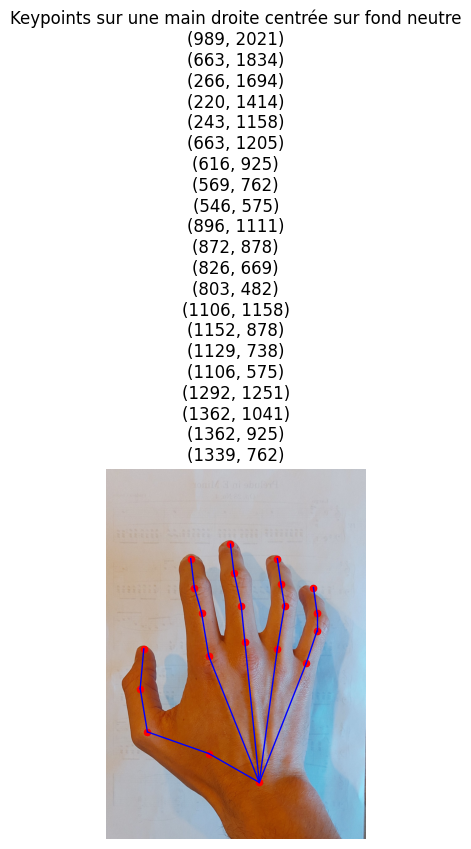

In [9]:
from PIL import Image as PILImage
from mmpose.apis import inference_topdown
import numpy as np
import matplotlib.pyplot as plt

# Définition du squelette de la main pour le tracé du squelette reliant les keypoints
HAND_SKELETON = [
    (0, 1), (1, 2), (2, 3), (3, 4),       # pouce
    (0, 5), (5, 6), (6, 7), (7, 8),       # index
    (0, 9), (9,10), (10,11), (11,12),     # majeur
    (0,13), (13,14), (14,15), (15,16),    # annulaire
    (0,17), (17,18), (18,19), (19,20)     # auriculaire
]

def draw_hand_skeleton(hand_keypoints): # Fournir les coordonnées des keypoints associés à UNE main
    # Tracé des keypoints
    for (x, y) in hand_keypoints:
        plt.scatter(x, y, c='red', s=20)

    # Tracé du squelette
    for i, j in HAND_SKELETON:
        x_vals = [hand_keypoints[i, 0], hand_keypoints[j, 0]]
        y_vals = [hand_keypoints[i, 1], hand_keypoints[j, 1]]
        plt.plot(x_vals, y_vals, c='blue', linewidth=1)

img_path = '/content/images/main_fond_neutre.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path, bboxes=[[0, 0, W, H]], bbox_format='xyxy')

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite centrée sur fond neutre\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# II. Main droite seule sur piano

Le modèle n'a pas de difficulté particulière pour placer les keypoints sur une main dans des conditions idéales (la main est l'unique objet dans le cadre, fond neutre, luminosité acceptable...). Avant de passer à la vidéo, il convient de vérifier que notre modèle est capable de détecter correctement une main lorsque celle-ci est posée sur un piano.

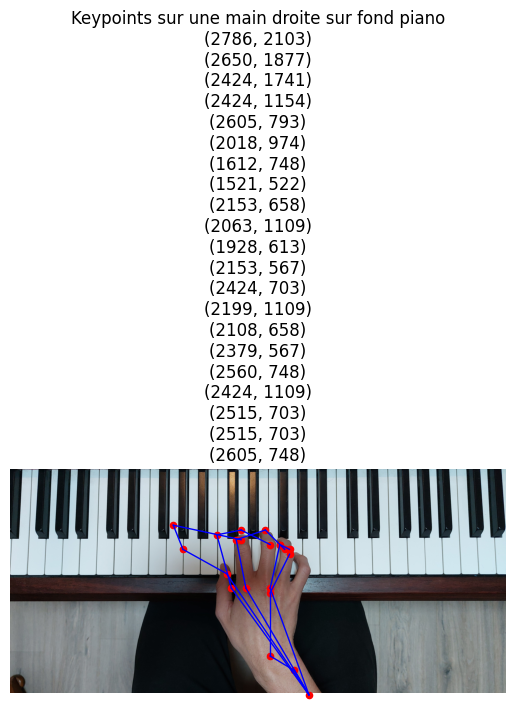

In [24]:
img_path = '/content/images/main_fond_piano.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()


On observe que la main n'est pas bien détectée, essayons en rognant l'image pour conserver uniquement la partie autour de la main que l'on veut détecter.

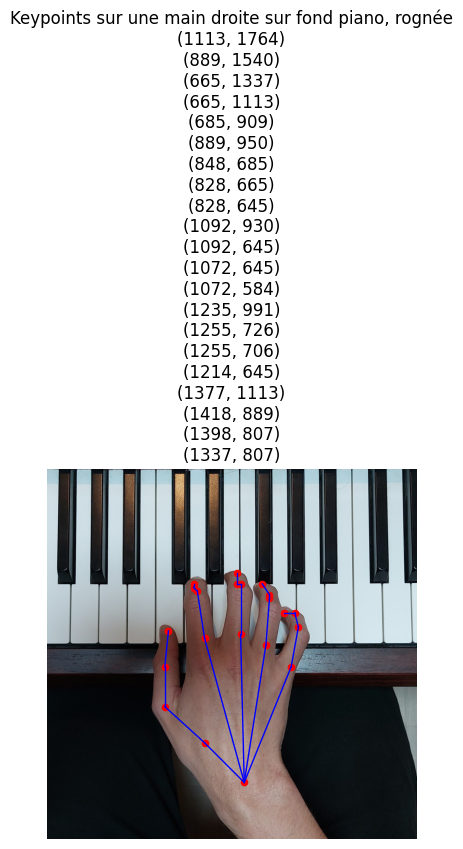

In [23]:
img_path = '/content/images/main_fond_piano_rognee.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

On observe que le modèle fonctionne lorsque l'image contient principalement la main même lorsqu'elle posée sur un piano dans des conditions qu'on aurait sur les vidéos que l'on souhaite traiter. Ce résultat est en fait attendu, le paramètre bboxes, "bounding boxes", lorsque l'on fait une inférence correspond aux zones de l'image dans lesquels une main est censée se trouver, en utilisant toute l'image (ou en ne renseignant pas le paramètre) comme bounding box, on indique au modèle que l'image est principalement composée de la main à mapper. Pour régler ce problème, on peut donc découper chaque frame que l'on souhaite traiter au préalable afin de ne garder que la main.

# Découpage de l'image

In [12]:
# On va utiliser le framework MediaPipe de Google

# On crée un ensemble d'options pour le détecteur ainsi que le détecteur de mains
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
# num_hands = 2 car on veut détecter au plus 2 mains, fonctionne aussi pour les images à 1 main grâce au paramètre de confiance
options = vision.HandLandmarkerOptions(base_options = base_options, num_hands = 2, min_hand_detection_confidence = 0.5)
detector = vision.HandLandmarker.create_from_options(options)

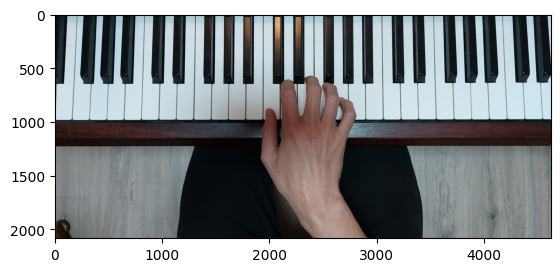

In [13]:
import cv2

img_path = '/content/images/main_fond_piano.jpg'

# CV2 lit les images au format BGR au lieu de RGB
img_bgr = cv2.imread(img_path)
# On convertit en RGB au lieu de BGR
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)

In [14]:
# Création de l'image à analyser et détection des mains sur l'image
mp_image = Image(image_format = mp.ImageFormat.SRGB, data = img_rgb)
detection_results = detector.detect(mp_image)

In [15]:
hauteur, largeur, _ = img_rgb.shape
hand_bboxes = []

for hand_landmarks in detection_results.hand_landmarks:
    xs = [point.x for point in hand_landmarks]
    ys = [point.y for point in hand_landmarks]

    x1 = int(min(xs) * largeur)
    y1 = int(min(ys) * hauteur)
    x2 = int(max(xs) * largeur)
    y2 = int(max(ys) * hauteur)

    hand_bboxes.append((x1, y1, x2, y2))

print(hand_bboxes)

[(1982, 605, 2751, 1730)]


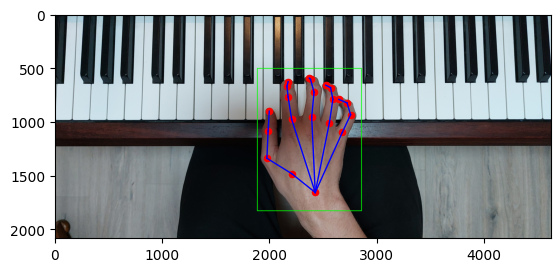

In [16]:
img = img_rgb.copy()
# Ajout d'un offset pour avoir l'ensemble de la main dans la bounding box
OFFSET_X = 100
OFFSET_Y = 100

for (x1, y1, x2, y2) in hand_bboxes:
    x_min = max(0,x1 - OFFSET_X)
    x_max = min(x2 + OFFSET_X, largeur)
    y_min = max(0,y1 - OFFSET_Y)
    y_max = min(y2 + OFFSET_Y, hauteur)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)

pose_results = inference_topdown(model, img_path, bboxes=hand_bboxes, bbox_format='xyxy')

plt.figure()
plt.imshow(np.array(img))

for pred in pose_results:
  keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
  draw_hand_skeleton(keypoints)

Extraction de chaque frame de la vidéo

On va maintenant transformer la vidéo en une suite de frames. On peut pour cela utiliser un pas pour l'extraction afin d'éviter des temps de calcul trop longs / utiliser trop de mémoire.

In [17]:
video_path = "/content/video/gamme_do_majeur.mp4"

# Pas pour l'extraction
step = 0
STEP_SIZE = 10

video = cv2.VideoCapture(video_path)
frame_id = 0
while True:
  ret, frame = video.read()
  if not ret:
     break
  if step % STEP_SIZE == 0:
    cv2.imwrite(f"full_frames/frame_{frame_id:03d}.png", frame)
    step = 0
  frame_id += 1
  step += 1;

video.release()

Redécoupage de chaque image en utilisant la logique vue précédemment

In [18]:
import glob

OFFSET_X = 200
OFFSET_Y = 100
# On enregistre les offsets pour revenir aux coordonnées originales
crop_offsets = {}

for img_path in sorted(glob.glob("/content/full_frames/*.png")):
  img_bgr = cv2.imread(img_path)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  # Détection de la main
  mp_image = Image(image_format = mp.ImageFormat.SRGB, data = img_rgb)
  results = detector.detect(mp_image)
  hauteur, largeur, _ = img_rgb.shape
  hand_bboxes = []
  for hand_landmarks in results.hand_landmarks:
    xs = [point.x for point in hand_landmarks]
    ys = [point.y for point in hand_landmarks]
    x1 = int(min(xs) * largeur)
    y1 = int(min(ys) * hauteur)
    x2 = int(max(xs) * largeur)
    y2 = int(max(ys) * hauteur)
    hand_bboxes.append((x1, y1, x2, y2))
    img = img_rgb.copy()
  for (x1, y1, x2, y2) in hand_bboxes:
    # Sélection de la zone désirée
    x_min = max(0,x1 - OFFSET_X)
    x_max = min(x2 + OFFSET_X, largeur)
    y_min = max(0,y1 - OFFSET_Y)
    y_max = min(y2 + OFFSET_Y, hauteur)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)
    # Enregistrement
    img_rognee = img[y_min:y_max, x_min:x_max]
    img_rognee_rgb = cv2.cvtColor(img_rognee, cv2.COLOR_RGB2BGR)
    cv2.imwrite(f'/content/hand_frames/{os.path.basename(img_path)}', img_rognee_rgb)
    # On garde les offsets pour repasser des coordonnées relatives de découpe aux coordonnées absolues de l'image
    crop_offsets[os.path.basename(img_path)] = (x_min, y_min)

print(crop_offsets)


{'frame_000.png': (513, 266), 'frame_010.png': (514, 278), 'frame_020.png': (506, 277), 'frame_030.png': (508, 272), 'frame_040.png': (514, 277), 'frame_050.png': (520, 281), 'frame_060.png': (519, 285), 'frame_070.png': (536, 293), 'frame_080.png': (600, 278), 'frame_090.png': (605, 251), 'frame_100.png': (669, 241), 'frame_110.png': (725, 217), 'frame_120.png': (733, 224), 'frame_130.png': (715, 231), 'frame_140.png': (701, 241), 'frame_150.png': (702, 245), 'frame_160.png': (712, 249), 'frame_170.png': (716, 229), 'frame_180.png': (708, 233), 'frame_190.png': (705, 234), 'frame_200.png': (706, 225), 'frame_210.png': (705, 237), 'frame_220.png': (708, 244), 'frame_230.png': (708, 238), 'frame_240.png': (711, 252), 'frame_250.png': (702, 252), 'frame_260.png': (708, 254), 'frame_270.png': (717, 233), 'frame_280.png': (717, 231), 'frame_290.png': (706, 214), 'frame_300.png': (684, 216), 'frame_310.png': (638, 233), 'frame_320.png': (633, 230), 'frame_330.png': (603, 230), 'frame_340.pn

# Prédiction sur chacune des frames

In [19]:
import pandas as pd

landmarks_list = []

for img_path in sorted(glob.glob("/content/hand_frames/*.png")):
  img_bgr = cv2.imread(img_path)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  im_np = np.array(img_rgb)
  # Prédictions
  results = inference_topdown(model, img_path)
  pred = results[0] # Une seule main
  keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
  scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

  # Création d'une ligne de données pour le dataframe
  row = {"frame": os.path.basename(img_path)}
  offset_x, offset_y = crop_offsets.get(os.path.basename(img_path), (0, 0))
  for i, (pt, score) in enumerate(zip(keypoints, scores)):
    row[f"x_{i}"] = pt[0] + offset_x
    row[f"y_{i}"] = pt[1] + offset_y
    row[f"score_{i}"] = score
  landmarks_list.append(row)

df = pd.DataFrame(landmarks_list)

In [ ]:
print(df.head(10))

In [ ]:
df_pos = df.drop(columns = df.columns[df.columns.str.startswith('score')])
df_pos = df_pos.drop(columns = ['frame'])
nb_images = df_pos.values.shape[0]
# On récupère l'ensemble des keypoints par image
keypoints = [[] for _ in range(nb_images)]
for i in range(nb_images):
  values = df_pos.iloc[i,:].values
  for j in range(0, len(values),2):
    point = (values[j],values[j+1])
    keypoints[i].append(point)

# On crée une liste de listes qui contiennent chacune l'évolution d'un point au cours du temps
keypoints_evolution = [[] for _ in range(len(keypoints[0]))]
for i in range(len(keypoints)):
  keypoint = []
  for j in range(len(keypoints[i])):
    keypoints_evolution[j].append(keypoints[i][j])

print(keypoints_evolution)
nb_keypoints = len(keypoints_evolution)
print(f"Nombre de keypoints : {nb_keypoints}")

# Calcul des trajectoires des Keypoints

In [ ]:
img = cv2.imread(glob.glob('/content/full_frames/*')[0])
hauteur, largeur = img.shape[:2]
print(hauteur,largeur)
for i in range(len(keypoints_evolution)):
  x, y = zip(*keypoints_evolution[i])
  plt.figure(figsize=(8, 4))
  y = [hauteur - y_i for y_i in y]

  plt.plot(x, y, label='Trajectoire')
  plt.plot(x[0], y[0], marker='o', markersize=10, color='green', label='Départ')
  plt.plot(x[-1], y[-1], marker='x', markersize=10, color='red', label='Arrivée')

  plt.title(f'Trajectoire du keypoint {i}')
  plt.xlabel('X')
  plt.ylabel('Y')

  plt.xlim(0, largeur)
  plt.ylim(0, hauteur)
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.legend()

  plt.show()

In [ ]:
# Supprime les images en double (peut arriver si la vidéo se fige entre sur plusieurs frames)
def merge_duplicates(points):
    l = [points[0]]
    for p in points[1:]:
        if p != l[-1]:
            l.append(p)
    return l

Calcul des vitesses


On définit un intervalle de temps $\Delta t$ entre deux images successives en divisant le pas (ici step) par la fréquence de la vidéo (ici $59$ FPS). On calcule ensuite pour chaque point de la main, le déplacement pendant $\Delta t$ en utilisant la distance euclidienne $d((x_i,y_i),(x_{i+1},y_{i+1})) = \sqrt{(x_{i+1} - x_i)^2 + (y_{i+1} - y_i)^2}$. On obtient alors la vitesse moyenne $v = \frac{d((x_i,y_i),(x_{i+1},y_{i+1}))}{\Delta t}$

In [ ]:
# la video est en 59 fps
delta = step/59
for i in range(nb_keypoints):
    points = keypoints_evolution[i]
    points = merge_duplicates(points)
    x, y = zip(*points)
    x = np.array(x)
    y = np.array(y)

    # np.diff : (x[i+1] - x[i])
    delta_x = np.diff(x)
    delta_y = np.diff(y)
    d = np.sqrt(delta_x**2 + delta_y**2)

    vitesse = d / delta
    t = np.arange(len(vitesse)) * delta

    plt.figure(figsize=(10, 6))
    plt.plot(t, vitesse, label='Vitesse')
    plt.scatter(t, vitesse, s=50)

    plt.title(f'Évolution de la Vitesse en fonction du Temps du keypoint {i}')
    plt.xlabel('Temps t')
    plt.ylabel('Vitesse')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

Les observations obtenues pour la trajectoire et la vitesse des keypoints correspond bien à la réalité. La trajectoire est bien cyclique ce qui est attendu car on fait un aller retour sur la gameme et la main finit dans la même position que celle dans laquelle elle a commencé.

De même les graphes de la vitesse montrent que tous les keypoinst suivent le même motif, ils restent relativement statiques sauf à deux occurences qui correspondent aux passages de mi à fa sur la montée et de fa à mi sur la descente.

On peut de plus noter que lors de la montée les keypoints du pouce accélèrent légèrement plus tôt que les autres ce qui correspond au fait que le pouce passe en dessous de la main avant que le reste suive, de même dans la descente avec les keypoints du majeur.

# Suite du projet


*   Main gauche
*   Extensions importantes de la main (au moins octave, ajustement de l'offset pour la bounding box de mediapipe)
*   Analyser les deux mains simultanément
*   Différenciation main gauche/main droite (cas où la main gauche passe à droite de la main droite)
*   Détection des touches pressées (modèle en 3d ?)


# III. Main gauche seule sur fond neutre



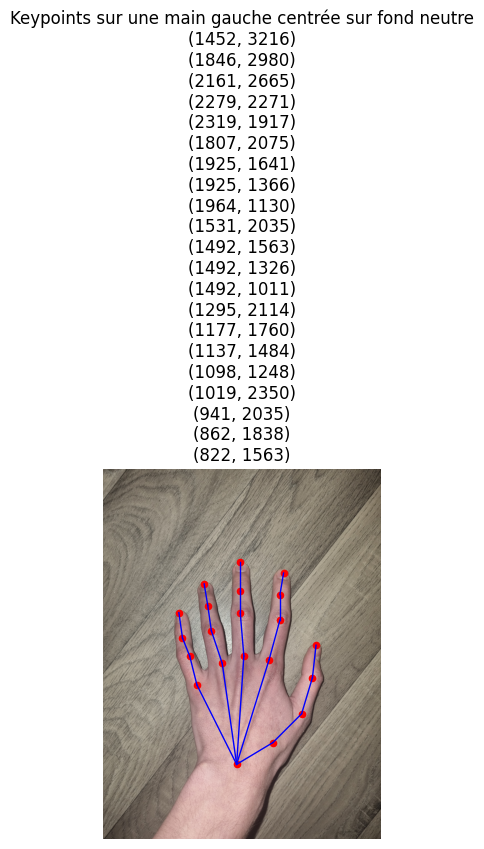

In [36]:
from PIL import Image as PILImage
from PIL import ImageOps
#J'ai importé ImageOps ça pcq j'avais un pb avec l'orientation de mon image, et c'est la solution que j'ai trouvée
from mmpose.apis import inference_topdown
import numpy as np
import matplotlib.pyplot as plt

# Définition du squelette de la main pour le tracé du squelette reliant les keypoints
HAND_SKELETON = [
    (0, 1), (1, 2), (2, 3), (3, 4),       # pouce
    (0, 5), (5, 6), (6, 7), (7, 8),       # index
    (0, 9), (9,10), (10,11), (11,12),     # majeur
    (0,13), (13,14), (14,15), (15,16),    # annulaire
    (0,17), (17,18), (18,19), (19,20)     # auriculaire
]

def draw_hand_skeleton(hand_keypoints): # Fournir les coordonnées des keypoints associés à UNE main
    # Tracé des keypoints
    for (x, y) in hand_keypoints:
        plt.scatter(x, y, c='red', s=20)

    # Tracé du squelette
    for i, j in HAND_SKELETON:
        x_vals = [hand_keypoints[i, 0], hand_keypoints[j, 0]]
        y_vals = [hand_keypoints[i, 1], hand_keypoints[j, 1]]
        plt.plot(x_vals, y_vals, c='blue', linewidth=1)

img_path = '/content/images/main_gauche.jpg' # à importer manuellement dans le notebook


img_pil = PILImage.open(img_path)
img_pil = ImageOps.exif_transpose(img_pil).convert("RGB")
im_np = np.array(img_pil)
W, H = img_pil.size
results = inference_topdown(model, img_path, bboxes=[[0, 0, W, H]], bbox_format='xyxy')

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main gauche centrée sur fond neutre\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# IV. Main gauche seule sur piano


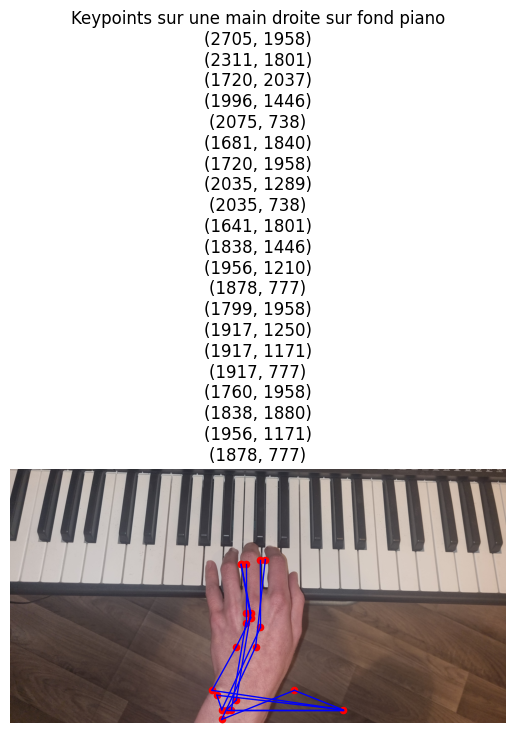

In [26]:
img_path = '/content/images/main_gauche_fond_piano.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()


On observe que la main n'est pas bien détectée, essayons en rognant l'image pour conserver uniquement la partie autour de la main que l'on veut détecter.

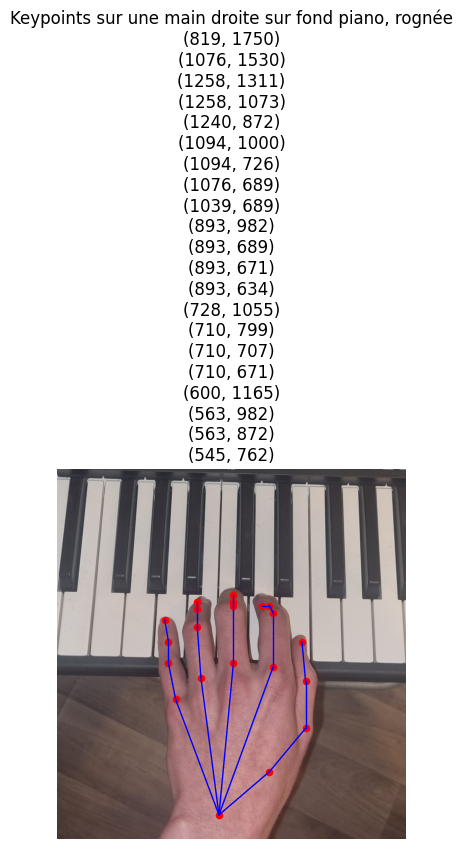

In [37]:
img_path = '/content/images/main_gauche_fond_piano_rognee.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

# V. Mains seules écartées

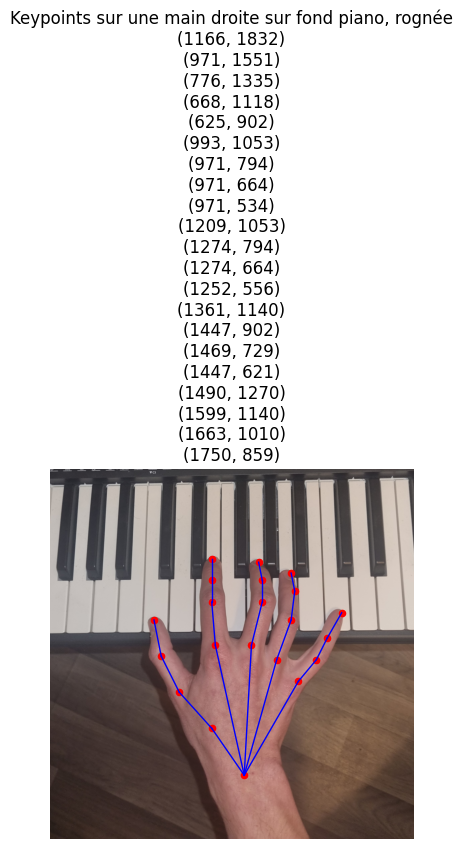

In [40]:
img_path = '/content/images/main_droite_ecartee_rognee.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

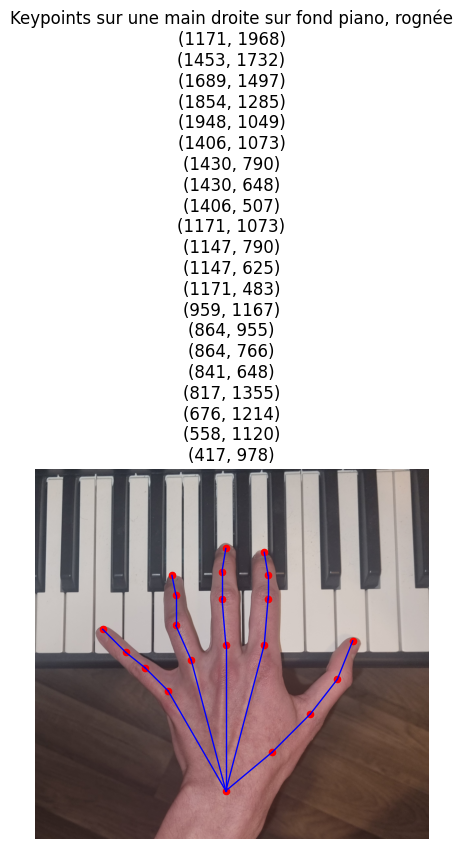

In [41]:
img_path = '/content/images/main_gauche_ecartee_rognee.jpg' # à importer manuellement dans le notebook

im_pil = PILImage.open(img_path).convert('RGB')
im_np = np.array(im_pil)
W, H = im_pil.size
results = inference_topdown(model, img_path)

pred = results[0] # Une seule main
keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
scores = pred.pred_instances.keypoint_scores[0]  # shape (21,)

plt.figure()
plt.imshow(im_np)
plt.axis('off')
plt.title('Keypoints sur une main droite sur fond piano, rognée\n' +
          '\n'.join([str(tuple(map(int, point))) for point in keypoints]))

draw_hand_skeleton(keypoints)

plt.show()

In [44]:
# On va utiliser le framework MediaPipe de Google

# On crée un ensemble d'options pour le détecteur ainsi que le détecteur de mains
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
# num_hands = 2 car on veut détecter au plus 2 mains, fonctionne aussi pour les images à 1 main grâce au paramètre de confiance
options = vision.HandLandmarkerOptions(base_options = base_options, num_hands = 2, min_hand_detection_confidence = 0.5)
detector = vision.HandLandmarker.create_from_options(options)

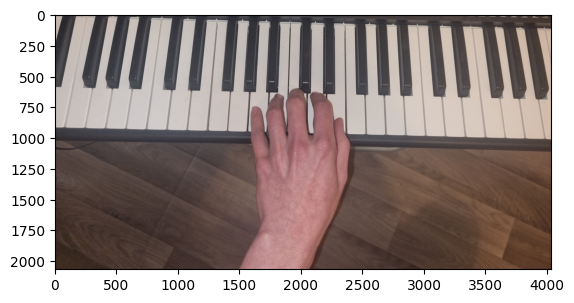

In [42]:
import cv2

img_path = '/content/images/main_gauche_fond_piano.jpg'

# CV2 lit les images au format BGR au lieu de RGB
img_bgr = cv2.imread(img_path)
# On convertit en RGB au lieu de BGR
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)

In [43]:
# Création de l'image à analyser et détection des mains sur l'image
mp_image = Image(image_format = mp.ImageFormat.SRGB, data = img_rgb)
detection_results = detector.detect(mp_image)

In [45]:
hauteur, largeur, _ = img_rgb.shape
hand_bboxes = []

for hand_landmarks in detection_results.hand_landmarks:
    xs = [point.x for point in hand_landmarks]
    ys = [point.y for point in hand_landmarks]

    x1 = int(min(xs) * largeur)
    y1 = int(min(ys) * hauteur)
    x2 = int(max(xs) * largeur)
    y2 = int(max(ys) * hauteur)

    hand_bboxes.append((x1, y1, x2, y2))

print(hand_bboxes)

[(1633, 646, 2371, 1770)]


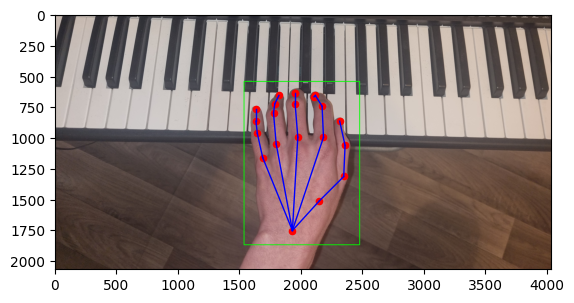

In [46]:
img = img_rgb.copy()
# Ajout d'un offset pour avoir l'ensemble de la main dans la bounding box
OFFSET_X = 100
OFFSET_Y = 100

for (x1, y1, x2, y2) in hand_bboxes:
    x_min = max(0,x1 - OFFSET_X)
    x_max = min(x2 + OFFSET_X, largeur)
    y_min = max(0,y1 - OFFSET_Y)
    y_max = min(y2 + OFFSET_Y, hauteur)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)

pose_results = inference_topdown(model, img_path, bboxes=hand_bboxes, bbox_format='xyxy')

plt.figure()
plt.imshow(np.array(img))

for pred in pose_results:
  keypoints = pred.pred_instances.keypoints[0]  # shape (21, 2)
  draw_hand_skeleton(keypoints)